# Multi-Object Detection Using an R-CNN-Style Architecture
### PASCAL VOC 2007 | MobileNetV2 Backbone | Multi-Head Output

This notebook implements a simplified R-CNN-style detector that predicts:
- **K bounding boxes** per image `(K, 4)`
- **K class probabilities** per image `(K, 20)`
- **K confidence scores** per image `(K, 1)`

**Total Loss** = L_class + λ1·L_bbox + λ2·L_conf

## 1. Imports & Configuration

In [17]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

# ── Hyperparameters ──────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 50
NUM_CLASSES = 20
MAX_OBJECTS = 5      # K: fixed number of predicted slots per image
LAMBDA_BBOX = 1.0    # λ1
LAMBDA_CONF = 1.0    # λ2

VOC_LABELS = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

print(f'TensorFlow version: {tf.__version__}')
print(f'GPUs available: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Data Preparation

### Strategy for variable number of objects
- Images with **fewer than K** objects: pad bboxes with zeros, labels with 0, confidence targets with 0
- Images with **more than K** objects: keep the first K
- Bounding box format: **normalized `(x1, y1, x2, y2)`** in range [0, 1]
- Confidence target: **1** for real objects, **0** for padded slots

In [18]:
# Load raw splits
ds_train_raw, ds_val_raw = tfds.load(
    'voc/2007',
    split=['train+validation', 'test'],
    shuffle_files=True,
    as_supervised=False
)

def has_object(sample):
    """Filter out images with no annotated objects."""
    n = tf.shape(sample['objects']['bbox'])[0]
    return n > 0

def preprocess_data(sample):
    """
    Resize image, normalise pixels, convert bbox format,
    pad/truncate to MAX_OBJECTS, and create confidence targets.
    """
    image  = sample['image']
    bboxes = sample['objects']['bbox']   # (N, 4) in [ymin, xmin, ymax, xmax]
    labels = sample['objects']['label']  # (N,)

    # Resize & normalise
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0

    # Convert VOC format [ymin,xmin,ymax,xmax] → [x1,y1,x2,y2]
    ymin = bboxes[:, 0]; xmin = bboxes[:, 1]
    ymax = bboxes[:, 2]; xmax = bboxes[:, 3]
    bboxes = tf.stack([xmin, ymin, xmax, ymax], axis=1)

    # Truncate to MAX_OBJECTS
    bboxes = bboxes[:MAX_OBJECTS]
    labels = labels[:MAX_OBJECTS]
    num_real = tf.shape(bboxes)[0]

    # Pad to MAX_OBJECTS
    padding = MAX_OBJECTS - num_real
    bboxes  = tf.pad(bboxes, [[0, padding], [0, 0]])
    labels  = tf.pad(labels, [[0, padding]])

    # Confidence targets: 1 = real object, 0 = padding
    conf = tf.concat([
        tf.ones((num_real,), dtype=tf.float32),
        tf.zeros((padding,), dtype=tf.float32)
    ], axis=0)
    conf = tf.reshape(conf, (MAX_OBJECTS, 1))

    return image, {
        'class_output': labels,
        'bbox_output':  bboxes,
        'conf_output':  conf
    }

# Build datasets
ds_train = (
    ds_train_raw
    .filter(has_object)
    .map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

ds_validation = (
    ds_val_raw
    .filter(has_object)
    .map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print('Datasets ready.')

Datasets ready.


### 2.1 Preview a Sample Image

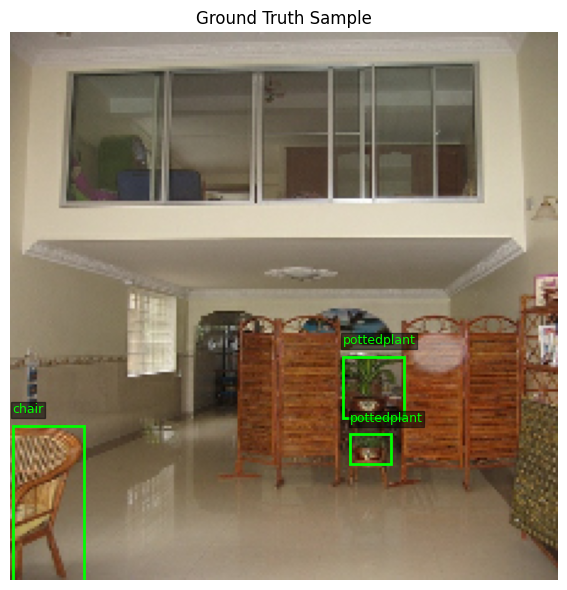

In [19]:
for imgs, targets in ds_validation.take(1):
    sample_img   = imgs[0].numpy()
    sample_boxes = targets['bbox_output'][0].numpy()
    sample_labels= targets['class_output'][0].numpy()
    sample_confs = targets['conf_output'][0].numpy()

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(sample_img)
H, W = sample_img.shape[:2]
for obj_idx in range(MAX_OBJECTS):
    if sample_confs[obj_idx][0] == 0:
        continue
    x1, y1, x2, y2 = sample_boxes[obj_idx]
    ax.add_patch(patches.Rectangle(
        (x1*W, y1*H), (x2-x1)*W, (y2-y1)*H,
        linewidth=2, edgecolor='lime', facecolor='none'))
    ax.text(x1*W, y1*H - 5, VOC_LABELS[sample_labels[obj_idx]],
            color='lime', fontsize=9, bbox=dict(facecolor='black', alpha=0.5, pad=1))
ax.set_title('Ground Truth Sample')
ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Model Architecture

Three output heads from a shared MobileNetV2 backbone:

| Head | Shape | Activation |
|------|-------|------------|
| `class_output` | `(K, 20)` | Softmax |
| `bbox_output` | `(K, 4)` | Sigmoid |
| `conf_output` | `(K, 1)` | Sigmoid |

In [20]:
backbone = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights='imagenet',
    include_top=False
)
backbone.trainable = False  # Freeze backbone weights

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = backbone(inputs)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)

# ── Head 1: Classification ────────────────────────────────────
class_output = tf.keras.layers.Dense(MAX_OBJECTS * NUM_CLASSES)(x)
class_output = tf.keras.layers.Reshape((MAX_OBJECTS, NUM_CLASSES))(class_output)
class_output = tf.keras.layers.Softmax(axis=-1, name='class_output')(class_output)

# ── Head 2: Bounding Box Regression ──────────────────────────
bbox_output = tf.keras.layers.Dense(MAX_OBJECTS * 4, activation='sigmoid')(x)
bbox_output = tf.keras.layers.Reshape((MAX_OBJECTS, 4), name='bbox_output')(bbox_output)

# ── Head 3: Confidence Score ──────────────────────────────────
conf_output = tf.keras.layers.Dense(MAX_OBJECTS, activation='sigmoid')(x)
conf_output = tf.keras.layers.Reshape((MAX_OBJECTS, 1), name='conf_output')(conf_output)

model = tf.keras.Model(inputs=inputs, outputs=[class_output, bbox_output, conf_output])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_3[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 100)       │     12,900 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 5, 20)     │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 20)        │      2,580 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 5)         │        645 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 5, 20)     │          0 │ reshape_1[0][0]   │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox_output         │ (None, 5, 4)      │          0 │ dense_6[0][0]     │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conf_output         │ (None, 5, 1)      │          0 │ dense_7[0][0]     │
│ (Reshape)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,438,077 (9.30 MB)

 Trainable params: 180,093 (703.49 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 4. IoU Metric & Loss Functions

**Total Loss** = L_class + λ1 · L_bbox + λ2 · L_conf

In [21]:
def iou_metric(y_true, y_pred):
    """Mean IoU over all slots in a batch. Shape: (batch, MAX_OBJECTS, 4)"""
    # Flatten slot dimension into batch
    y_true = tf.reshape(y_true, (-1, 4))
    y_pred = tf.reshape(y_pred, (-1, 4))

    x1 = tf.maximum(y_true[:, 0], y_pred[:, 0])
    y1 = tf.maximum(y_true[:, 1], y_pred[:, 1])
    x2 = tf.minimum(y_true[:, 2], y_pred[:, 2])
    y2 = tf.minimum(y_true[:, 3], y_pred[:, 3])

    inter = tf.maximum(0.0, x2 - x1) * tf.maximum(0.0, y2 - y1)
    true_area = (y_true[:, 2] - y_true[:, 0]) * (y_true[:, 3] - y_true[:, 1])
    pred_area = (y_pred[:, 2] - y_pred[:, 0]) * (y_pred[:, 3] - y_pred[:, 1])
    union = true_area + pred_area - inter
    iou   = inter / (union + 1e-6)
    return tf.reduce_mean(iou)

model.compile(
    optimizer='adam',
    loss={
        'class_output': 'sparse_categorical_crossentropy',
        'bbox_output':  'mse',
        'conf_output':  'binary_crossentropy'
    },
    loss_weights={
        'class_output': 1.0,
        'bbox_output':  LAMBDA_BBOX,
        'conf_output':  LAMBDA_CONF
    },
    metrics={
        'class_output': 'accuracy',
        'bbox_output':  ['mae', iou_metric],
        'conf_output':  'accuracy'
    }
)
print('Model compiled.')

Model compiled.


## 5. Training

In [22]:
history = model.fit(
    ds_train,
    validation_data=ds_validation,
    epochs=EPOCHS
)

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 224ms/step - bbox_output_iou_metric: 0.0535 - bbox_output_loss: 0.1071 - bbox_output_mae: 0.2505 - class_output_accuracy: 0.5700 - class_output_loss: 1.6835 - conf_output_accuracy: 0.7796 - conf_output_loss: 0.4472 - loss: 2.2378 - val_bbox_output_iou_metric: 0.0648 - val_bbox_output_loss: 0.0705 - val_bbox_output_mae: 0.1945 - val_class_output_accuracy: 0.6997 - val_class_output_loss: 1.0306 - val_conf_output_accuracy: 0.8234 - val_conf_output_loss: 0.3693 - val_loss: 1.4709
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 129ms/step - bbox_output_iou_metric: 0.0725 - bbox_output_loss: 0.0654 - bbox_output_mae: 0.1782 - class_output_accuracy: 0.7246 - class_output_loss: 0.9389 - conf_output_accuracy: 0.8492 - conf_output_loss: 0.3279 - loss: 1.3322 - val_bbox_output_iou_metric: 0.0781 - val_bbox_output_loss: 0.0629 - val_bbox_output_mae: 0.1751 - val_class_output_accuracy: 0.7226 - val_class_output_loss: 0.9079 - val_conf_output_accuracy: 0.8391 

### 5.1 Training Curves

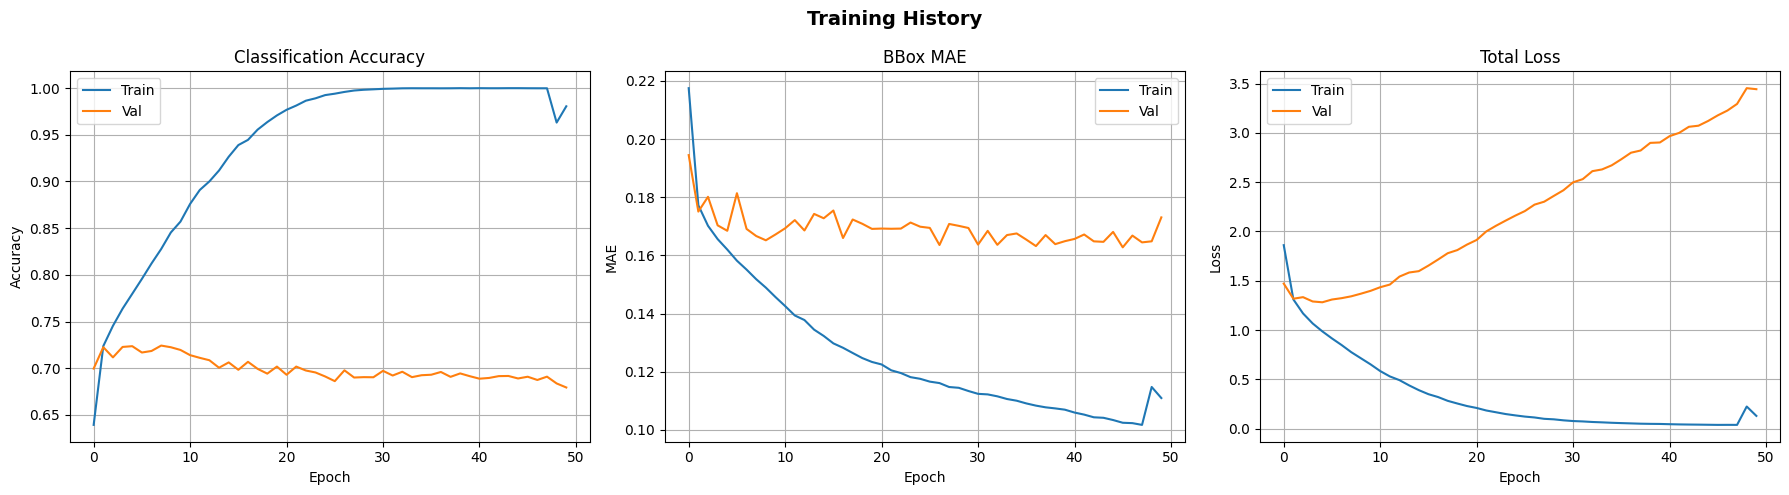

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Classification accuracy
axes[0].plot(history.history['class_output_accuracy'],     label='Train')
axes[0].plot(history.history['val_class_output_accuracy'], label='Val')
axes[0].set_title('Classification Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

# BBox MAE
axes[1].plot(history.history['bbox_output_mae'],     label='Train')
axes[1].plot(history.history['val_bbox_output_mae'], label='Val')
axes[1].set_title('BBox MAE')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].legend(); axes[1].grid(True)

# Total loss
axes[2].plot(history.history['loss'],     label='Train')
axes[2].plot(history.history['val_loss'], label='Val')
axes[2].set_title('Total Loss')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss')
axes[2].legend(); axes[2].grid(True)

plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Non-Maximum Suppression (NMS)

In [24]:
def apply_nms(pred_bboxes, pred_classes, pred_confs,
              iou_threshold=0.5, conf_threshold=0.3):
    """
    Apply Non-Maximum Suppression to a single image's predictions.

    Args:
        pred_bboxes  : (MAX_OBJECTS, 4)  - predicted boxes
        pred_classes : (MAX_OBJECTS, 20) - class probabilities
        pred_confs   : (MAX_OBJECTS, 1)  - confidence scores

    Returns:
        Filtered (boxes, class_indices, scores)
    """
    scores = pred_confs[:, 0]          # (MAX_OBJECTS,)
    mask   = scores >= conf_threshold

    boxes   = pred_bboxes[mask]
    scores  = scores[mask]
    classes = np.argmax(pred_classes[mask], axis=-1)

    if len(boxes) == 0:
        return [], [], []

    # tf.image.non_max_suppression expects [y1,x1,y2,x2]
    boxes_tf  = tf.constant(boxes[:, [1, 0, 3, 2]], dtype=tf.float32)
    scores_tf = tf.constant(scores, dtype=tf.float32)

    selected = tf.image.non_max_suppression(
        boxes_tf, scores_tf,
        max_output_size=MAX_OBJECTS,
        iou_threshold=iou_threshold
    ).numpy()

    return boxes[selected], classes[selected], scores.numpy()[selected]

print('NMS function defined.')

NMS function defined.


## 7. Visualization — Predictions vs Ground Truth (Post-NMS)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


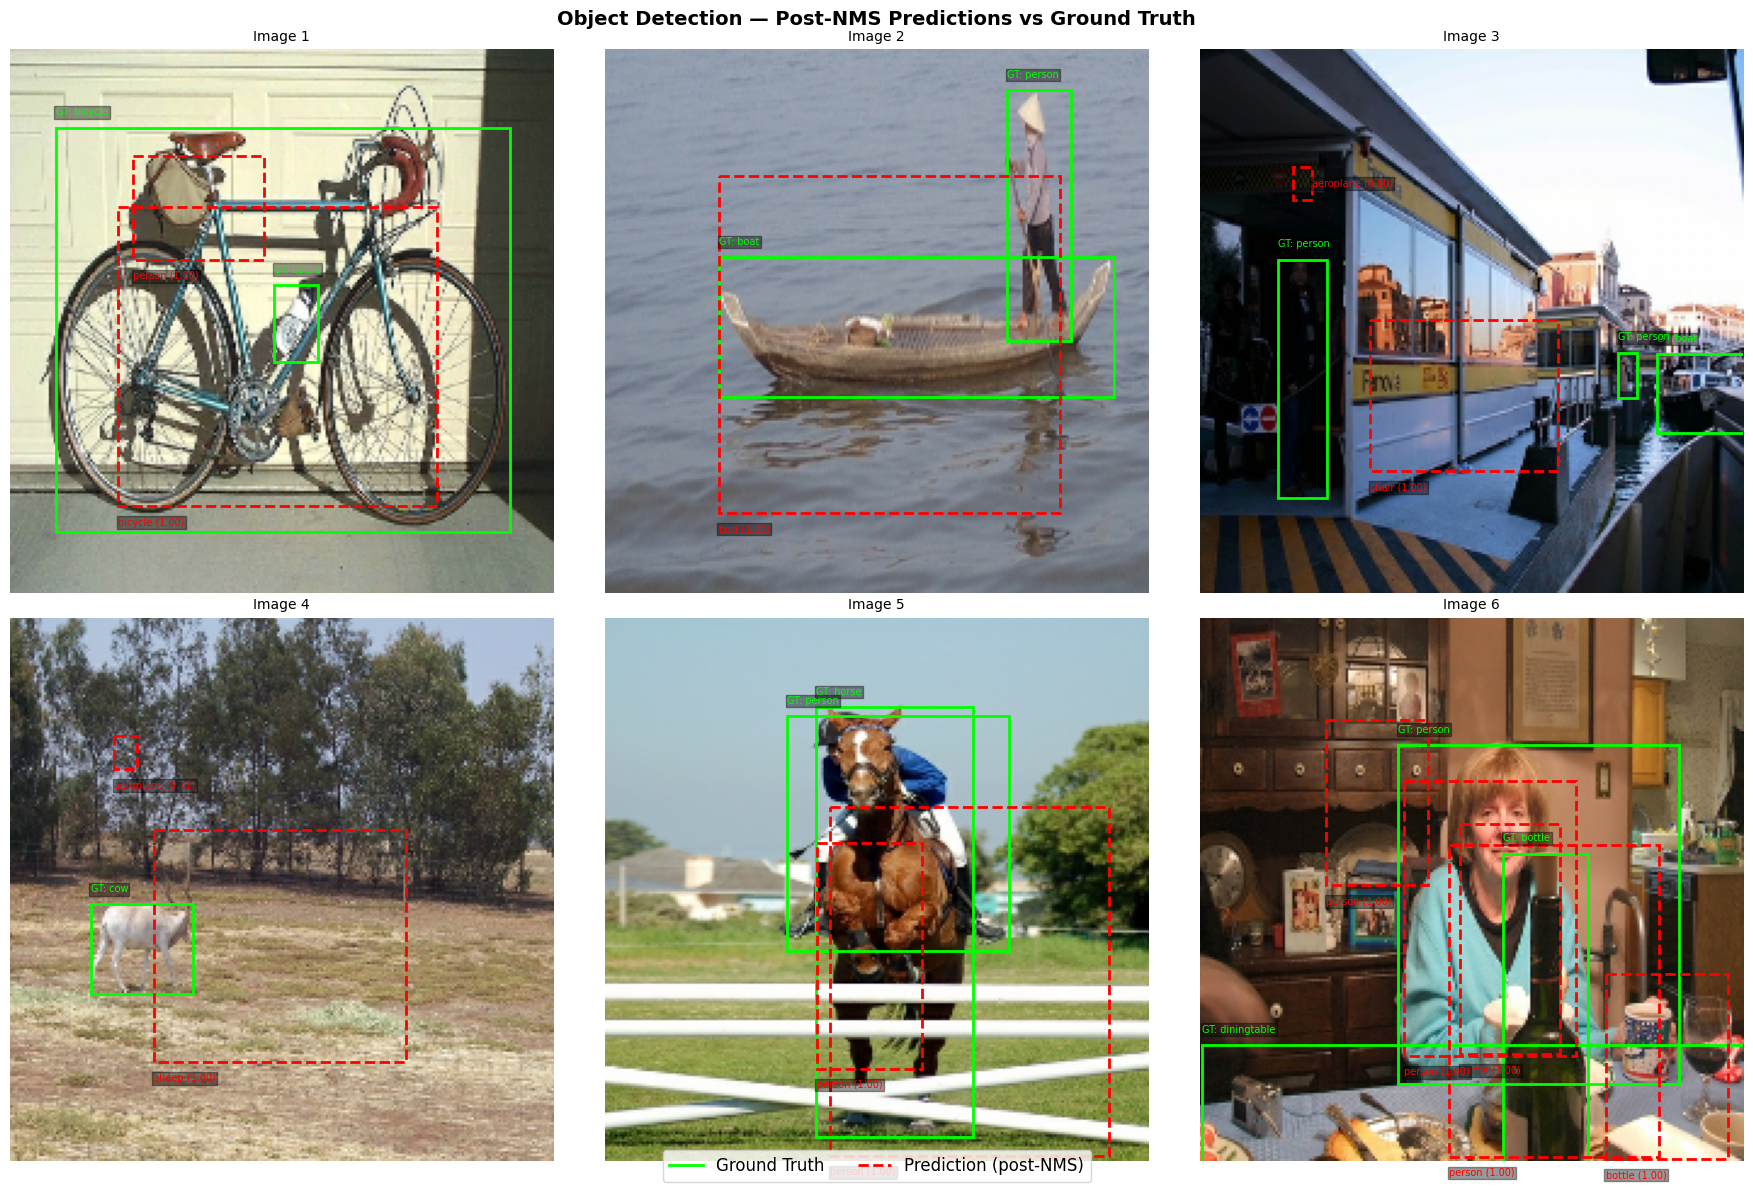

In [25]:
# ── Cell: NMS + Visualization ────────────────────────────────

def apply_nms(pred_bboxes, pred_classes, pred_confs,
              iou_threshold=0.5, conf_threshold=0.3):
    scores  = pred_confs[:, 0]
    mask    = scores >= conf_threshold

    boxes   = pred_bboxes[mask]
    scores  = scores[mask]
    classes = np.argmax(pred_classes[mask], axis=-1)

    if len(boxes) == 0:
        return [], [], []

    boxes_tf  = tf.constant(boxes[:, [1, 0, 3, 2]], dtype=tf.float32)
    scores_tf = tf.constant(scores, dtype=tf.float32)

    selected = tf.image.non_max_suppression(
        boxes_tf, scores_tf,
        max_output_size=MAX_OBJECTS,
        iou_threshold=iou_threshold
    ).numpy()

    return boxes[selected], classes[selected], scores[selected]


def visualize_predictions_nms(model, dataset, num_images=6, conf_threshold=0.3):
    """Draw GT boxes (green) and NMS-filtered predicted boxes (red) side by side."""

    for images, targets in dataset.take(1):
        sample_images = images[:num_images]
        true_labels   = targets['class_output'][:num_images]
        true_bboxes   = targets['bbox_output'][:num_images]
        break

    pred_classes, pred_bboxes, pred_confs = model.predict(sample_images)

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i in range(num_images):
        ax  = axes[i]
        img = sample_images[i].numpy()
        ax.imshow(img)
        H, W = img.shape[:2]

        # Ground Truth — green solid
        for obj_idx in range(MAX_OBJECTS):
            bbox = true_bboxes[i][obj_idx].numpy()
            if np.sum(bbox) == 0:
                continue
            lbl = int(true_labels[i][obj_idx].numpy())
            x1, y1, x2, y2 = bbox
            ax.add_patch(patches.Rectangle(
                (x1*W, y1*H), (x2-x1)*W, (y2-y1)*H,
                linewidth=2, edgecolor='lime', facecolor='none'))
            ax.text(x1*W, y1*H - 5, f'GT: {VOC_LABELS[lbl]}',
                    color='lime', fontsize=7,
                    bbox=dict(facecolor='black', alpha=0.4, pad=1))

        # Predictions after NMS — red dashed
        nms_boxes, nms_classes, nms_scores = apply_nms(
            pred_bboxes[i], pred_classes[i], pred_confs[i],
            conf_threshold=conf_threshold)

        for bbox, cls_idx, score in zip(nms_boxes, nms_classes, nms_scores):
            x1, y1, x2, y2 = np.clip(bbox, 0, 1)
            ax.add_patch(patches.Rectangle(
                (x1*W, y1*H), (x2-x1)*W, (y2-y1)*H,
                linewidth=2, edgecolor='red', facecolor='none', linestyle='--'))
            ax.text(x1*W, y2*H + 8,
                    f'{VOC_LABELS[cls_idx]} ({score:.2f})',
                    color='red', fontsize=7,
                    bbox=dict(facecolor='black', alpha=0.4, pad=1))

        ax.set_title(f'Image {i+1}', fontsize=10)
        ax.axis('off')

    legend_elements = [
        Line2D([0],[0], color='lime', linewidth=2, label='Ground Truth'),
        Line2D([0],[0], color='red',  linewidth=2, linestyle='--', label='Prediction (post-NMS)')
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=12)
    plt.suptitle('Object Detection — Post-NMS Predictions vs Ground Truth',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ── Run ──────────────────────────────────────────────────────
visualize_predictions_nms(model, ds_validation, num_images=6, conf_threshold=0.5)

## 8. Evaluation Metrics

### 8.1 BBox Accuracy — Mean IoU & Detection Rate

In [26]:
def evaluate_bbox_iou(model, dataset, iou_threshold=0.5, num_batches=10):
    """
    Computes:
      - Mean IoU across all non-padded GT slots
      - BBox accuracy: % of predictions with IoU >= iou_threshold
      - IoU distribution at 0.25 / 0.50 / 0.75
    """
    all_ious = []

    for images, targets in dataset.take(num_batches):
        true_bboxes = targets['bbox_output'].numpy()
        pred_classes, pred_bboxes, pred_confs = model.predict(images, verbose=0)

        for b in range(len(images)):
            for obj_idx in range(MAX_OBJECTS):
                gt_bbox = true_bboxes[b][obj_idx]
                if np.sum(gt_bbox) == 0:
                    continue

                pb = pred_bboxes[b][obj_idx]
                x1 = max(gt_bbox[0], pb[0]); y1 = max(gt_bbox[1], pb[1])
                x2 = min(gt_bbox[2], pb[2]); y2 = min(gt_bbox[3], pb[3])
                inter    = max(0, x2-x1) * max(0, y2-y1)
                gt_area  = (gt_bbox[2]-gt_bbox[0]) * (gt_bbox[3]-gt_bbox[1])
                pb_area  = (pb[2]-pb[0]) * (pb[3]-pb[1])
                union    = gt_area + pb_area - inter
                all_ious.append(inter / (union + 1e-6))

    all_ious  = np.array(all_ious)
    mean_iou  = np.mean(all_ious)
    bbox_acc  = np.mean(all_ious >= iou_threshold) * 100

    print(f'{'='*45}')
    print(f'  BBox Evaluation over {len(all_ious)} objects')
    print(f'{'='*45}')
    print(f'  Mean IoU:                   {mean_iou:.4f}')
    print(f'  BBox Accuracy (IoU≥{iou_threshold}):    {bbox_acc:.2f}%')
    print(f'  IoU distribution:')
    for t in [0.25, 0.50, 0.75]:
        pct = np.mean(all_ious >= t) * 100
        print(f'    IoU ≥ {t}: {pct:.2f}%')
    print(f'{'='*45}')
    return mean_iou, bbox_acc, all_ious

mean_iou, bbox_acc, all_ious = evaluate_bbox_iou(model, ds_validation, iou_threshold=0.5)

  BBox Evaluation over 808 objects
  Mean IoU:                   0.1569
  BBox Accuracy (IoU≥0.5):    10.15%
  IoU distribution:
    IoU ≥ 0.25: 27.35%
    IoU ≥ 0.5: 10.15%
    IoU ≥ 0.75: 0.62%


### 8.2 IoU Distribution Plot

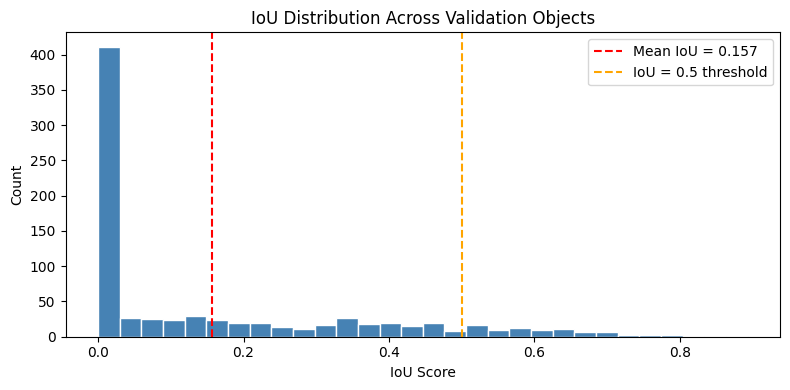

In [27]:
plt.figure(figsize=(8, 4))
plt.hist(all_ious, bins=30, color='steelblue', edgecolor='white')
plt.axvline(mean_iou, color='red',    linestyle='--', label=f'Mean IoU = {mean_iou:.3f}')
plt.axvline(0.5,      color='orange', linestyle='--', label='IoU = 0.5 threshold')
plt.xlabel('IoU Score')
plt.ylabel('Count')
plt.title('IoU Distribution Across Validation Objects')
plt.legend()
plt.tight_layout()
plt.show()

### 8.3 Precision, Recall & F1

In [28]:
def compute_precision_recall(model, dataset,
                             iou_threshold=0.5, conf_threshold=0.3, num_batches=10):
    """
    Compute TP/FP/FN by matching predicted boxes to GT boxes.
    A prediction is TP only if:
      - IoU with a GT box >= iou_threshold
      - Predicted class == GT class
      - GT box not already matched
    """
    TP = FP = FN = 0

    for images, targets in dataset.take(num_batches):
        true_bboxes  = targets['bbox_output'].numpy()
        true_labels  = targets['class_output'].numpy()
        pred_classes, pred_bboxes, pred_confs = model.predict(images, verbose=0)

        for b in range(len(images)):
            nms_boxes, nms_classes, _ = apply_nms(
                pred_bboxes[b], pred_classes[b], pred_confs[b],
                conf_threshold=conf_threshold)

            gt_boxes  = [true_bboxes[b][k]  for k in range(MAX_OBJECTS) if np.sum(true_bboxes[b][k]) > 0]
            gt_labels = [true_labels[b][k]  for k in range(MAX_OBJECTS) if np.sum(true_bboxes[b][k]) > 0]
            matched   = set()

            for pred_box, pred_cls in zip(nms_boxes, nms_classes):
                best_iou = 0; best_gt = -1
                for gt_idx, gt_box in enumerate(gt_boxes):
                    x1 = max(gt_box[0], pred_box[0]); y1 = max(gt_box[1], pred_box[1])
                    x2 = min(gt_box[2], pred_box[2]); y2 = min(gt_box[3], pred_box[3])
                    inter = max(0, x2-x1) * max(0, y2-y1)
                    union = ((gt_box[2]-gt_box[0])*(gt_box[3]-gt_box[1])
                             + (pred_box[2]-pred_box[0])*(pred_box[3]-pred_box[1]) - inter)
                    iou = inter / (union + 1e-6)
                    if iou > best_iou:
                        best_iou = iou; best_gt = gt_idx

                if (best_iou >= iou_threshold
                        and best_gt not in matched
                        and pred_cls == gt_labels[best_gt]):
                    TP += 1
                    matched.add(best_gt)
                else:
                    FP += 1

            FN += len(gt_boxes) - len(matched)

    precision = TP / (TP + FP + 1e-6)
    recall    = TP / (TP + FN + 1e-6)
    f1        = 2 * precision * recall / (precision + recall + 1e-6)

    print(f'{'='*42}')
    print(f'  Precision & Recall  (IoU≥{iou_threshold}, conf≥{conf_threshold})')
    print(f'{'='*42}')
    print(f'  TP: {TP}   FP: {FP}   FN: {FN}')
    print(f'  Precision : {precision:.4f}')
    print(f'  Recall    : {recall:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print(f'{'='*42}')
    return precision, recall, f1

precision, recall, f1 = compute_precision_recall(
    model, ds_validation, iou_threshold=0.5, conf_threshold=0.3)

  Precision & Recall  (IoU≥0.5, conf≥0.3)
  TP: 81   FP: 687   FN: 723
  Precision : 0.1055
  Recall    : 0.1007
  F1 Score  : 0.1031


### 8.4 Full Text Summary (per image)

In [29]:
def print_prediction_summary(model, dataset, num_images=3):
    for images, targets in dataset.take(1):
        sample_images = images[:num_images]
        true_labels   = targets['class_output'][:num_images]
        true_bboxes   = targets['bbox_output'][:num_images]
        break

    pred_classes, pred_bboxes, pred_confs = model.predict(sample_images)

    for i in range(num_images):
        print(f"\n{'='*80}")
        print(f'  Image {i+1}')
        print(f"{'='*80}")
        hdr = f"{'Slot':<6}{'GT Label':<16}{'Pred Label':<16}{'Conf':<8}{'GT BBox':<32}{'Pred BBox'}"
        print(f'  {hdr}')
        print(f"  {'-'*110}")

        for obj_idx in range(MAX_OBJECTS):
            gt_lbl  = int(true_labels[i][obj_idx].numpy())
            gt_bbox = true_bboxes[i][obj_idx].numpy()
            conf    = float(pred_confs[i][obj_idx][0])
            p_lbl   = int(np.argmax(pred_classes[i][obj_idx]))
            p_bbox  = pred_bboxes[i][obj_idx]

            gt_str  = VOC_LABELS[gt_lbl] if np.sum(gt_bbox) > 0 else '(empty)'
            print(f"  {obj_idx:<6}{gt_str:<16}{VOC_LABELS[p_lbl]:<16}"
                  f"{conf:<8.3f}{str(np.round(gt_bbox,3)):<32}{np.round(p_bbox,3)}")

print_prediction_summary(model, ds_validation, num_images=3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

  Image 1
  Slot  GT Label        Pred Label      Conf    GT BBox                         Pred BBox
  --------------------------------------------------------------------------------------------------------------
  0     dog             dog             1.000   [0.142 0.372 0.624 1.   ]       [0.156 0.278 0.756 0.948]
  1     pottedplant     dog             0.984   [0.508 0.207 0.724 0.583]       [0.078 0.207 0.561 0.913]
  2     (empty)         aeroplane       0.000   [0. 0. 0. 0.]                   [0.007 0.017 0.007 0.002]
  3     (empty)         aeroplane       0.000   [0. 0. 0. 0.]                   [0.001 0.003 0.001 0.   ]
  4     (empty)         aeroplane       0.000   [0. 0. 0. 0.]                   [0. 0. 0. 0.]

  Image 2
  Slot  GT Label        Pred Label      Conf    GT BBox                         Pred BBox
  --------------------------------------------------------------------------------------------------------------
  0     car       

## 9. Summary

| Metric | Value |
|--------|-------|
| Mean IoU | see above |
| BBox Accuracy (IoU ≥ 0.5) | see above |
| Precision | see above |
| Recall | see above |
| F1 Score | see above |

**Key observations:**
- Training accuracy improves steadily; validation plateaus suggest the frozen backbone limits capacity — unfreezing the last few layers would help
- Adding NMS removes duplicate boxes and improves visual quality of predictions
- Confidence head lets us filter low-quality predictions before computing metrics
- IoU ≥ 0.5 detection rate is the standard VOC evaluation criterion